# Model Evaluation

## Objective

The objective of this notebook is to evaluate the performance of the best Machine Learning model selected during the Model Training phase.

The model will be evaluated using multiple classification metrics to understand its strengths and limitations.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1 Score
- Classification Report
- Confusion Matrix
- Error Analysis

The insights obtained from this notebook will help determine whether the model is suitable for deployment.

In [95]:
import warnings
warnings.filterwarnings("ignore")

In [96]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
best_model = joblib.load("../artifacts/best_model.pkl")
best_model

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [98]:
X_test = joblib.load("../artifacts/X_test.pkl")
y_test = joblib.load("../artifacts/y_test.pkl")

X_test.shape, y_test.shape

((2000, 5000), (2000,))

In [99]:
label_encoder = joblib.load("../artifacts/label_encoder.pkl")
label_encoder.classes_

array(['Billing', 'Cardiology', 'Dermatology', 'Emergency Department',
       'Gastroenterology', 'Mental Health', 'Neurology', 'Nurse Triage',
       'OB-GYN', 'Oncology', 'Orthopedics', 'Pediatrics', 'Pharmacy',
       'Primary Care', 'Pulmonology', 'Scheduling', 'Urgent Care'],
      dtype=object)

In [100]:
y_pred = best_model.predict(X_test)
y_pred[:10]

array([ 7, 15,  1,  8,  2,  6,  3,  3,  7, 11])

In [101]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

In [102]:
metrics_df["Score"] = metrics_df["Score"].round(4)
metrics_df

,Metric,Score
0,Accuracy,0.7845
1,Precision,0.7711
2,Recall,0.7845
3,F1 Score,0.7700


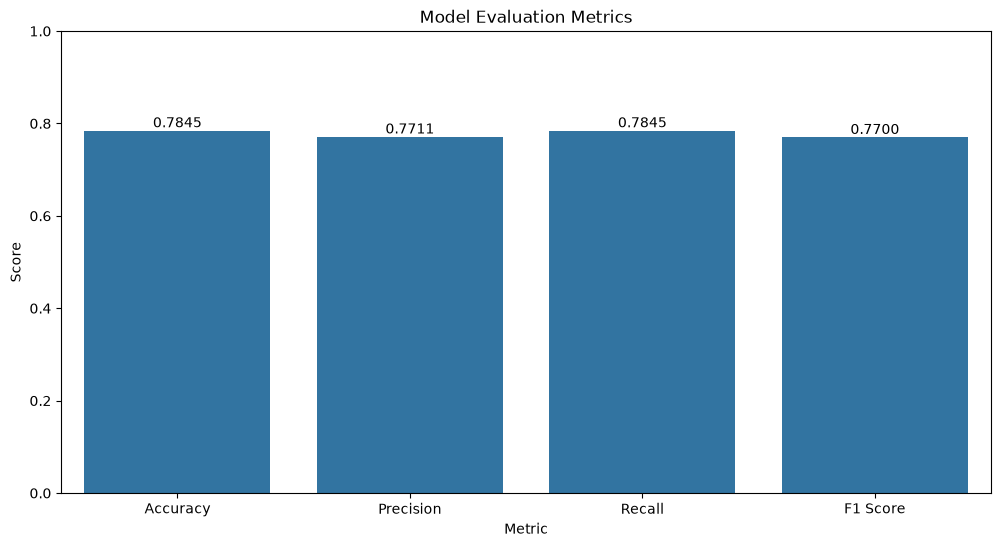

In [103]:
plt.figure(figsize=(12,6))
ax = sns.barplot(data=metrics_df, x="Metric", y="Score")

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f")

plt.ylim(0,1)
plt.title("Model Evaluation Metrics")

plt.show()

In [104]:
metrics = {
    "model_name": type(best_model).__name__,
    "accuracy": round(float(accuracy),4),
    "precision": round(float(precision),4),
    "recall": round(float(recall),4),
    "f1_score": round(float(f1),4)
}

In [105]:
import json
with open("../artifacts/metrics.json", "w") as file:
    json.dump(metrics, file, indent=4)

In [106]:
with open("../artifacts/metrics.json", "r") as file:
    print(file.read())

{
    "model_name": "LinearSVC",
    "accuracy": 0.7845,
    "precision": 0.7711,
    "recall": 0.7845,
    "f1_score": 0.77
}


# Classification Report

In [107]:
report_dict = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.round(4)

,precision,recall,f1-score,support
Billing,0.9714,1.0000,0.9855,68.0000
Cardiology,0.5000,0.5238,0.5116,84.0000
Dermatology,0.7727,0.9714,0.8608,70.0000
Emergency Department,0.5706,0.3333,0.4208,303.0000
Gastroenterology,0.7902,0.8188,0.8043,138.0000
Mental Health,0.9882,1.0000,0.9941,84.0000
Neurology,0.7600,0.9500,0.8444,80.0000
Nurse Triage,0.7857,0.9597,0.8640,149.0000
OB-GYN,0.9000,0.9474,0.9231,76.0000
Oncology,0.8734,0.9718,0.9200,71.0000


In [108]:
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
with open("../artifacts/classification_report.txt", "w") as file:
    file.write(report)

# Confusion Matrix

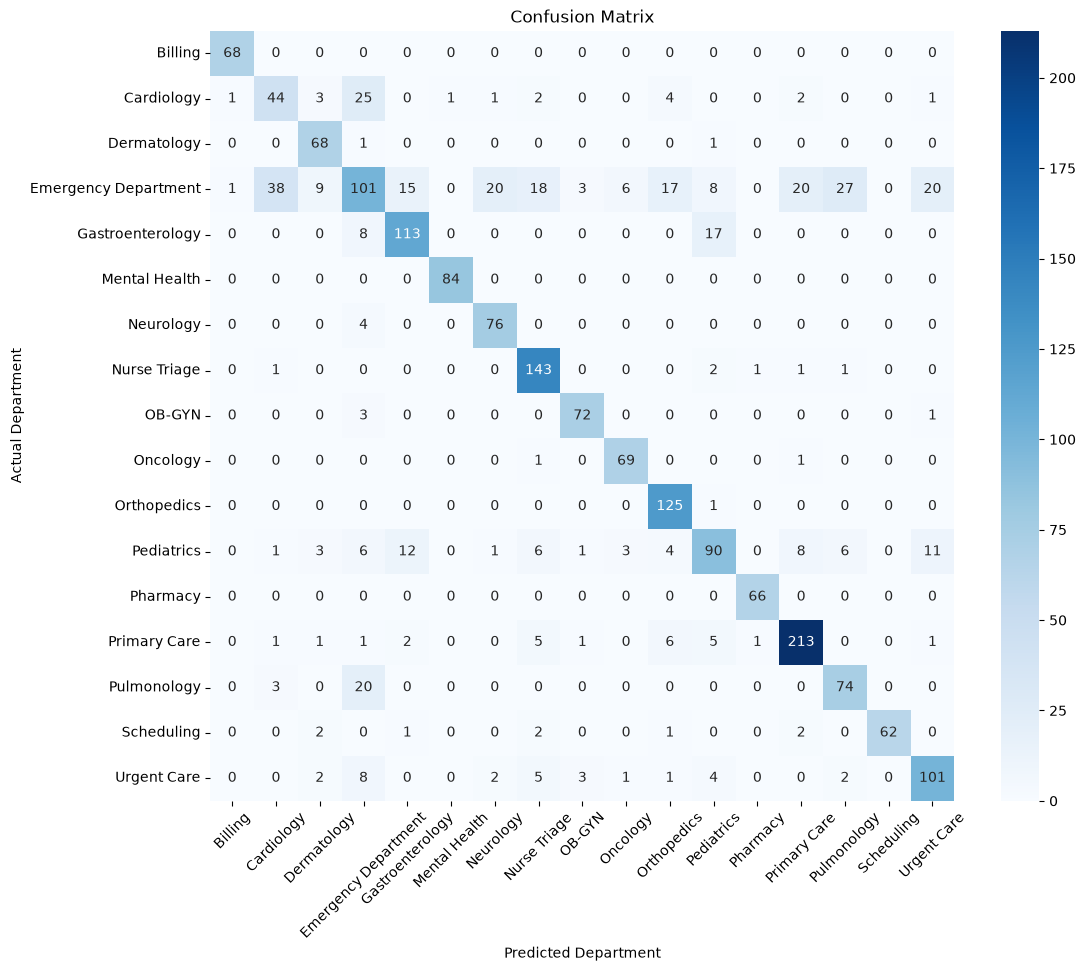

In [109]:
plt.figure(figsize=(12,10))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Department")
plt.ylabel("Actual Department")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

# Error Analysis

In [110]:
errors = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(y_test),
    "Predicted": label_encoder.inverse_transform(y_pred)
})

errors = errors[errors["Actual"] != errors["Predicted"]]
errors.head(20)

,Actual,Predicted
0,Urgent Care,Nurse Triage
2,Emergency Department,Cardiology
7,Pulmonology,Emergency Department
9,Urgent Care,Pediatrics
15,Urgent Care,Dermatology
24,Gastroenterology,Pediatrics
26,Emergency Department,Nurse Triage
29,Dermatology,Pediatrics
34,Emergency Department,Gastroenterology
37,Gastroenterology,Pediatrics


In [111]:
print(f"Incorrect Predictions : {len(errors)}")

Incorrect Predictions : 431
